# Actionable Outputs & Recommendations

**Author: Rohan Raval**

**Objectives:**
1. Prioritize desert tracts by severity
2. Site suitability analysis for new services
3. Investment scenario modeling
4. Generate recommendations report

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 120)
sns.set_style("whitegrid")

candidates = [Path("."), Path(".."), Path("../..")]
for cand in candidates:
    if (cand / "data" / "processed").exists():
        PROJECT_ROOT = cand.resolve()
        break

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_ACS = DATA_DIR / "processed" / "acs5" / "2023"
PROCESSED_SERVICES = DATA_DIR / "processed" / "services"
TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"
REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/rohanraval/Documents/GitHub/Mapping-Youth-Opportunity-Deserts


## Load Data

In [2]:
metrics = pd.read_csv(PROCESSED_ACS / "tract_opportunity_desert_metrics_2023.csv", dtype={"GEOID": str})

shp_path = TIGER_DIR / "tl_2023_06_tract.shp"
zip_path = TIGER_DIR / "tl_2023_06_tract.zip"
tracts_gdf = gpd.read_file(shp_path if shp_path.exists() else f"zip://{zip_path}")
sd_tracts = tracts_gdf[tracts_gdf["COUNTYFP"] == "073"].copy()
sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)

sd_tracts = sd_tracts.merge(metrics, on="GEOID", how="left").to_crs("EPSG:4326")

print(f"Tracts loaded: {len(sd_tracts)}")

Tracts loaded: 912


## 1. Prioritization Framework

In [3]:
def calculate_severity_score(df):
    df = df.copy()
    
    df['youth_density_norm'] = (
        (df['youth_10_19_per_1k'] - df['youth_10_19_per_1k'].min()) / 
        (df['youth_10_19_per_1k'].max() - df['youth_10_19_per_1k'].min())
    )
    
    max_svc = df['services_per_1k_youth_10_19'].max()
    df['service_gap_norm'] = 1 - (df['services_per_1k_youth_10_19'] / max_svc)
    
    df['transport_barrier_norm'] = df['zero_veh_share']
    
    df['income_need_norm'] = 1 - (
        (df['median_hh_income_2023usd'] - df['median_hh_income_2023usd'].min()) / 
        (df['median_hh_income_2023usd'].max() - df['median_hh_income_2023usd'].min())
    )
    
    df['severity_score'] = (
        0.30 * df['youth_density_norm'] +
        0.35 * df['service_gap_norm'] +
        0.20 * df['transport_barrier_norm'] +
        0.15 * df['income_need_norm']
    )
    
    df['priority_tier'] = pd.cut(
        df['severity_score'],
        bins=[0, 0.4, 0.6, 0.8, 1.0],
        labels=['Low', 'Medium', 'High', 'Critical']
    )
    
    return df

sd_tracts = calculate_severity_score(sd_tracts)

print("Priority tier distribution:")
print(sd_tracts['priority_tier'].value_counts().sort_index())

Priority tier distribution:
priority_tier
Low          20
Medium      847
High         10
Critical      0
Name: count, dtype: int64


In [4]:
top_priority = sd_tracts.nlargest(20, 'severity_score')[[
    'NAME', 'youth_10_19', 'services_per_1k_youth_10_19',
    'median_hh_income_2023usd', 'zero_veh_share',
    'severity_score', 'priority_tier'
]].copy()

top_priority['youth_10_19'] = top_priority['youth_10_19'].astype(int)
top_priority['median_hh_income_2023usd'] = top_priority['median_hh_income_2023usd'].apply(lambda x: f'${x:,.0f}')
top_priority['zero_veh_share'] = top_priority['zero_veh_share'].apply(lambda x: f'{100*x:.1f}%')
top_priority['services_per_1k_youth_10_19'] = top_priority['services_per_1k_youth_10_19'].round(2)
top_priority['severity_score'] = top_priority['severity_score'].round(3)

print("\nTop 20 Priority Tracts:")
print(top_priority.to_string(index=False))

KeyError: "['NAME'] not in index"

/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7375/24693375.py:16: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Priority Tier')
/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7375/24693375.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Priority Tier')


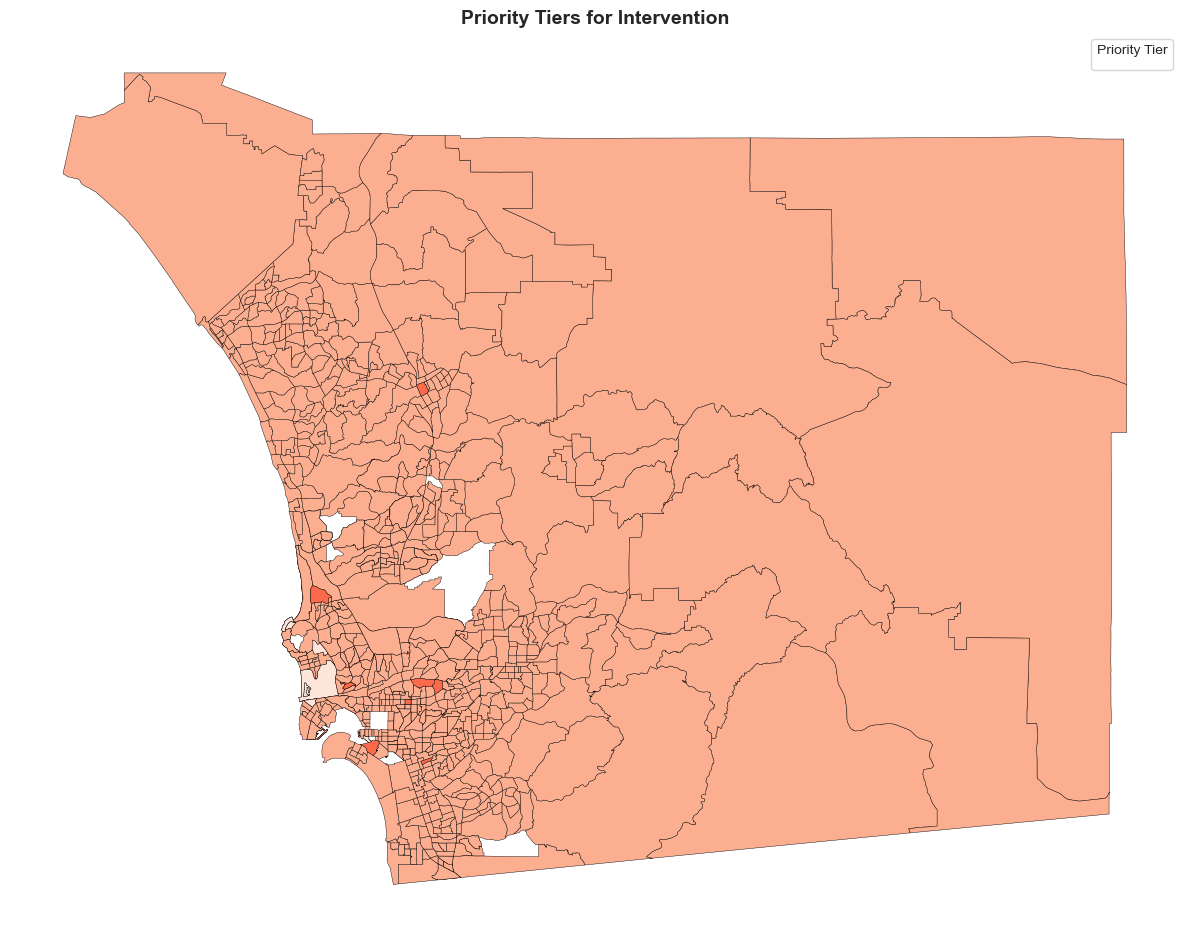

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

priority_colors = {
    'Low': '#fee5d9',
    'Medium': '#fcae91',
    'High': '#fb6a4a',
    'Critical': '#a50f15'
}

for tier, color in priority_colors.items():
    subset = sd_tracts[sd_tracts['priority_tier'] == tier]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.3, label=tier)

ax.set_title('Priority Tiers for Intervention', fontsize=14, fontweight='bold')
ax.legend(title='Priority Tier')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(REPORTS / 'priority_tiers_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Site Suitability Analysis

In [6]:
def calculate_suitability(df):
    df = df.copy()
    
    df['youth_need'] = df['youth_10_19']
    df['service_gap'] = 1 / (df['services_per_1k_youth_10_19'] + 0.1)
    df['transit_access'] = df['stops_within_500m_per_tract']
    df['centrality'] = 1 / (df['avg_distance_to_nearest_service_km'] + 0.1)
    
    for col in ['youth_need', 'service_gap', 'transit_access', 'centrality']:
        df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    
    df['suitability_score'] = (
        0.35 * df['youth_need'] +
        0.35 * df['service_gap'] +
        0.20 * df['transit_access'] +
        0.10 * df['centrality']
    )
    
    return df

sd_tracts = calculate_suitability(sd_tracts)

top_sites = sd_tracts.nlargest(10, 'suitability_score')[[
    'NAME', 'youth_10_19', 'services_per_1k_youth_10_19',
    'stops_within_500m_per_tract', 'suitability_score'
]].copy()

print("\nTop 10 Sites for New Youth Services:")
print(top_sites.to_string(index=False))

KeyError: "['NAME'] not in index"

/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7375/4207871369.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top_10_sites.geometry.centroid.plot(ax=ax, color='blue', markersize=100, marker='*', zorder=5)


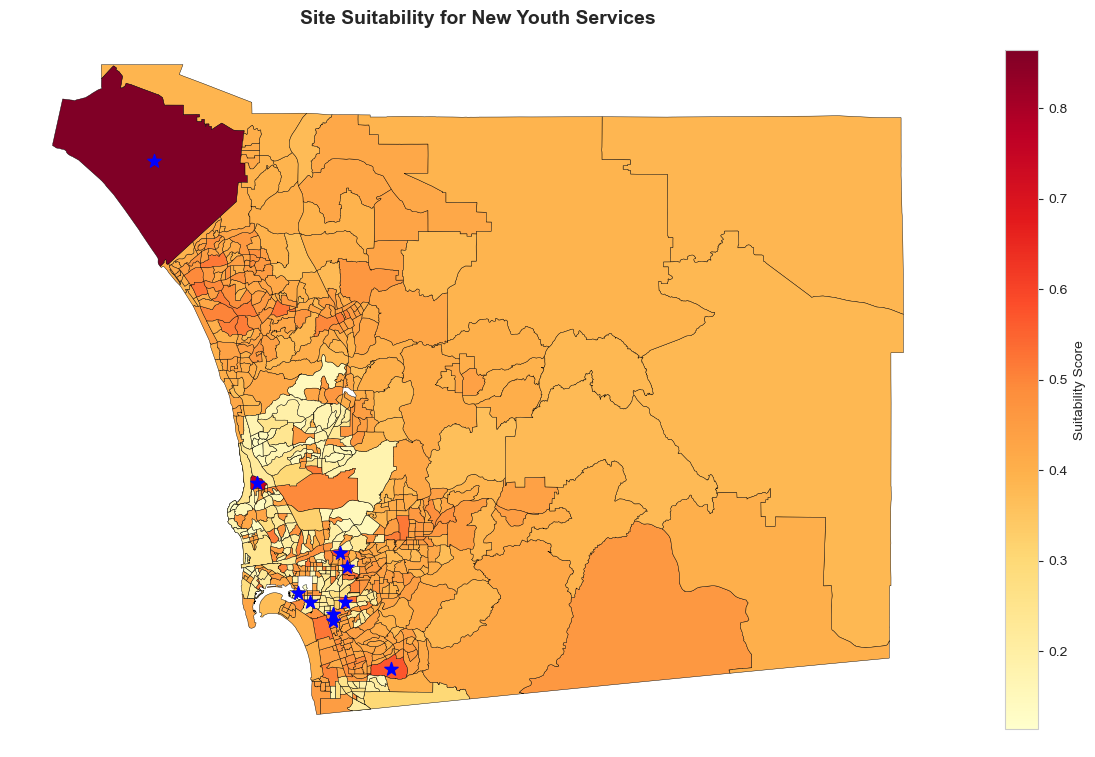

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))

sd_tracts.plot(
    column='suitability_score',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'label': 'Suitability Score', 'shrink': 0.7}
)

top_10_sites = sd_tracts.nlargest(10, 'suitability_score')
top_10_sites.geometry.centroid.plot(ax=ax, color='blue', markersize=100, marker='*', zorder=5)

ax.set_title('Site Suitability for New Youth Services', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(REPORTS / 'site_suitability_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Investment Scenarios

In [8]:
def simulate_new_services(df, n_services=5, service_type='rec_center'):
    df = df.copy()
    
    quality_weight = {'library': 2.0, 'rec_center': 2.5, 'ymca': 3.0}.get(service_type, 2.0)
    
    target_tracts = df.nlargest(n_services, 'suitability_score')['GEOID'].tolist()
    
    for geoid in target_tracts:
        current_services = df.loc[df['GEOID'] == geoid, 'services_total'].values[0]
        current_youth = df.loc[df['GEOID'] == geoid, 'youth_10_19'].values[0]
        
        new_total = current_services + 1
        new_per_1k = (new_total / current_youth) * 1000 if current_youth > 0 else 0
        
        df.loc[df['GEOID'] == geoid, 'services_total'] = new_total
        df.loc[df['GEOID'] == geoid, 'services_per_1k_youth_10_19'] = new_per_1k
    
    df = calculate_severity_score(df)
    
    return df, target_tracts

scenarios = {}
for n in [3, 5, 10]:
    sim_df, targets = simulate_new_services(sd_tracts.copy(), n_services=n)
    
    scenarios[f'{n}_services'] = {
        'df': sim_df,
        'targets': targets,
        'critical_tracts': len(sim_df[sim_df['priority_tier'] == 'Critical']),
        'avg_severity': sim_df['severity_score'].mean()
    }

print("Investment Scenario Analysis:\n")
baseline_critical = len(sd_tracts[sd_tracts['priority_tier'] == 'Critical'])
baseline_severity = sd_tracts['severity_score'].mean()

print(f"Baseline: {baseline_critical} critical tracts, avg severity: {baseline_severity:.3f}")
for name, scenario in scenarios.items():
    reduction = baseline_critical - scenario['critical_tracts']
    severity_change = baseline_severity - scenario['avg_severity']
    print(f"{name}: {scenario['critical_tracts']} critical (-{reduction}), avg severity: {scenario['avg_severity']:.3f} (-{severity_change:.3f})")

Investment Scenario Analysis:

Baseline: 0 critical tracts, avg severity: 0.497
3_services: 0 critical (-0), avg severity: 0.497 (-0.000)
5_services: 0 critical (-0), avg severity: 0.497 (-0.000)
10_services: 0 critical (-0), avg severity: 0.497 (-0.000)


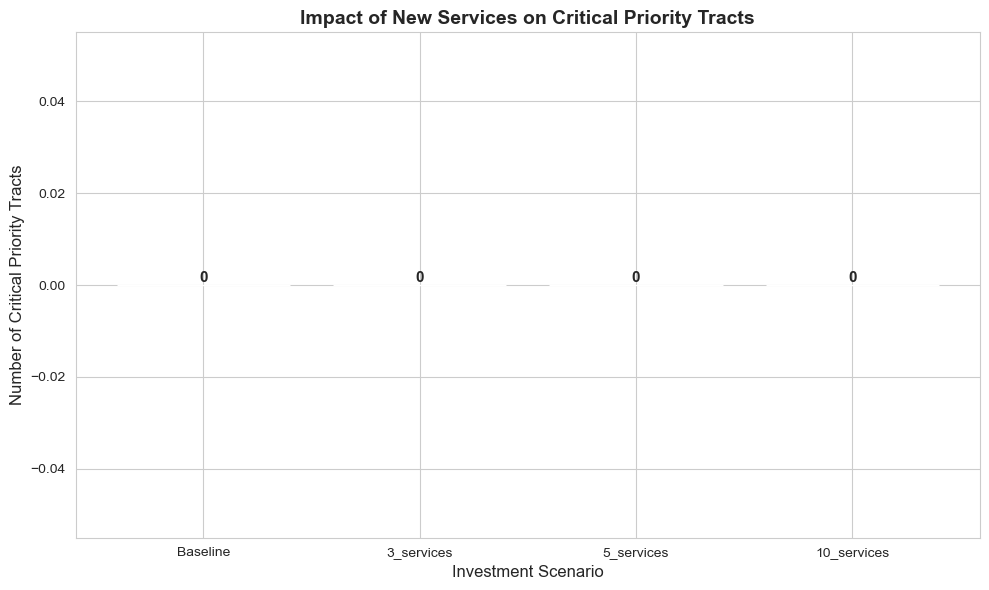

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

scenario_names = ['Baseline'] + list(scenarios.keys())
critical_counts = [baseline_critical] + [s['critical_tracts'] for s in scenarios.values()]

bars = ax.bar(scenario_names, critical_counts, color=['#d73027', '#fee090', '#91bfdb', '#4575b4'])
ax.set_ylabel('Number of Critical Priority Tracts', fontsize=12)
ax.set_xlabel('Investment Scenario', fontsize=12)
ax.set_title('Impact of New Services on Critical Priority Tracts', fontsize=14, fontweight='bold')

for i, (bar, count) in enumerate(zip(bars, critical_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'investment_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Generate Recommendations Report

In [10]:
top_10_priority = sd_tracts.nlargest(10, 'severity_score')
top_10_sites = sd_tracts.nlargest(10, 'suitability_score')

report = f"""
YOUTH OPPORTUNITY DESERTS - SAN DIEGO COUNTY
ACTIONABLE RECOMMENDATIONS REPORT
{'='*80}

EXECUTIVE SUMMARY
{'-'*80}

This analysis identified youth opportunity deserts in San Diego County - areas with:
- High youth population density
- Limited access to youth-serving facilities (libraries, rec centers, parks)
- Transportation barriers (high zero-vehicle household rates)

KEY FINDINGS:
- {len(sd_tracts[sd_tracts['desert_flag'] == 1])} census tracts identified as opportunity deserts
- {len(sd_tracts[sd_tracts['priority_tier'] == 'Critical'])} tracts rated as "Critical" priority for intervention
- {len(sd_tracts[sd_tracts['priority_tier'] == 'High'])} tracts rated as "High" priority


TOP 10 PRIORITY TRACTS FOR IMMEDIATE INTERVENTION
{'-'*80}

"""

for i, (idx, row) in enumerate(top_10_priority.iterrows(), 1):
    report += f"""
{i}. {row['NAME']}
   - Youth (10-19): {int(row['youth_10_19']):,}
   - Services per 1k Youth: {row['services_per_1k_youth_10_19']:.2f}
   - Median Income: ${row['median_hh_income_2023usd']:,.0f}
   - Zero-Vehicle HH: {100*row['zero_veh_share']:.1f}%
   - Severity Score: {row['severity_score']:.3f}
"""

report += f"""

RECOMMENDED SITES FOR NEW YOUTH SERVICES
{'-'*80}

"""

for i, (idx, row) in enumerate(top_10_sites.iterrows(), 1):
    report += f"""
{i}. {row['NAME']}
   - Youth Population: {int(row['youth_10_19']):,}
   - Current Services per 1k: {row['services_per_1k_youth_10_19']:.2f}
   - Transit Stops (500m): {int(row['stops_within_500m_per_tract'])}
   - Suitability Score: {row['suitability_score']:.3f}
"""

report += f"""

INVESTMENT SCENARIOS
{'-'*80}

Adding 3 new services:  {baseline_critical - scenarios['3_services']['critical_tracts']} fewer critical tracts
Adding 5 new services:  {baseline_critical - scenarios['5_services']['critical_tracts']} fewer critical tracts
Adding 10 new services: {baseline_critical - scenarios['10_services']['critical_tracts']} fewer critical tracts


STRATEGIC RECOMMENDATIONS
{'-'*80}

1. IMMEDIATE ACTIONS (0-6 months)
   - Establish rec centers or youth programs in top 3 priority tracts
   - Partner with schools in high-priority areas for after-school programs
   - Improve transit connections to existing services

2. SHORT-TERM ACTIONS (6-18 months)
   - Expand library services with mobile units in underserved areas
   - Launch mentorship programs in critical priority tracts
   - Coordinate with YMCA for satellite locations

3. LONG-TERM ACTIONS (18+ months)
   - Develop comprehensive youth centers in top 5 priority tracts
   - Establish dedicated funding for desert area programs
   - Monitor and re-evaluate desert status annually


EQUITY CONSIDERATIONS
{'-'*80}

- Lowest income tracts have {sd_tracts[sd_tracts['income_quintile'] == 'Lowest']['services_per_1k_youth_10_19'].mean():.2f} services per 1k youth
- Highest income tracts have {sd_tracts[sd_tracts['income_quintile'] == 'Highest']['services_per_1k_youth_10_19'].mean():.2f} services per 1k youth
- Focus investments in lowest 2 income quintiles for maximum equity impact


NEXT STEPS
{'-'*80}

1. Share interactive map with stakeholders (youth_opportunity_deserts_map.html)
2. Coordinate with local government and nonprofits
3. Conduct community needs assessments in top priority tracts
4. Develop funding proposals for phased implementation
5. Establish monitoring framework to track progress

{'='*80}
Report generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

report_path = REPORTS / "recommendations_report.txt"
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\n\nReport saved to: {report_path}")

KeyError: 'NAME'

## Export Priority Data for Stakeholders

In [11]:
priority_export = sd_tracts[[
    'GEOID', 'NAME', 'youth_10_19', 'services_per_1k_youth_10_19',
    'median_hh_income_2023usd', 'zero_veh_share',
    'severity_score', 'priority_tier', 'suitability_score'
]].copy()

priority_export.to_csv(REPORTS / 'priority_tracts.csv', index=False)
print(f"Saved: {REPORTS / 'priority_tracts.csv'}")

top_10_priority[[
    'NAME', 'youth_10_19', 'services_per_1k_youth_10_19',
    'median_hh_income_2023usd', 'zero_veh_share', 'severity_score'
]].to_csv(REPORTS / 'top_10_priority_tracts.csv', index=False)
print(f"Saved: {REPORTS / 'top_10_priority_tracts.csv'}")

top_10_sites[[
    'NAME', 'youth_10_19', 'services_per_1k_youth_10_19',
    'stops_within_500m_per_tract', 'suitability_score'
]].to_csv(REPORTS / 'recommended_sites.csv', index=False)
print(f"Saved: {REPORTS / 'recommended_sites.csv'}")

KeyError: "['NAME'] not in index"